In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## MultiResUNet Architecture
U-Net with MultiRes blocks (three chained 3x3 convs, concatenated, with a 1x1 residual shortcut) and ResPaths on the skip connections (Ibtehaz & Rahman, 2020).

In [38]:
class ConvBN(nn.Module):
    """Conv -> BN (-> ReLU)"""
    def __init__(self, in_ch, out_ch, k=3, act=True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=k // 2, bias=False),
                  nn.BatchNorm2d(out_ch)]
        if act:
            layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

def multires_out_channels(U, alpha=1.67):
    """Number of output channels of a MultiResBlock built with U filters."""
    W = U * alpha
    return int(W * 0.167) + int(W * 0.333) + int(W * 0.5)

class MultiResBlock(nn.Module):
    """MultiRes block (Ibtehaz & Rahman, 2020).
    Three chained 3x3 convs (a 3x3, 5x5 and 7x7 receptive-field approximation) whose outputs are
    concatenated, plus a 1x1 conv residual shortcut:
        out = BN( ReLU( BN(concat(c1, c2, c3)) + BN(Conv1x1(x)) ) )
    with c1, c2, c3 getting 1/6, 1/3 and 1/2 of W = alpha * U filters.
    One Dropout2d is applied at the block end (when use_dropout=True)."""
    def __init__(self, in_ch, U, alpha=1.67, dropout_rate=0.1, use_dropout=True):
        super().__init__()
        W = U * alpha
        f1, f2, f3 = int(W * 0.167), int(W * 0.333), int(W * 0.5)
        self.out_ch = f1 + f2 + f3

        self.shortcut = ConvBN(in_ch, self.out_ch, k=1, act=False)
        self.conv3x3 = ConvBN(in_ch, f1, k=3, act=True)
        self.conv5x5 = ConvBN(f1, f2, k=3, act=True)
        self.conv7x7 = ConvBN(f2, f3, k=3, act=True)
        self.bn_cat = nn.BatchNorm2d(self.out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.bn_out = nn.BatchNorm2d(self.out_ch)
        self.drop = nn.Dropout2d(dropout_rate) if use_dropout else nn.Identity()

    def forward(self, x):
        sc = self.shortcut(x)
        a = self.conv3x3(x)
        b = self.conv5x5(a)
        c = self.conv7x7(b)
        out = self.bn_cat(torch.cat([a, b, c], dim=1))
        out = self.relu(out + sc)
        out = self.bn_out(out)
        return self.drop(out)

class ResPath(nn.Module):
    """Residual path on a skip connection: `length` stacked (3x3 conv + 1x1 conv shortcut) residual units."""
    def __init__(self, in_ch, filters, length):
        super().__init__()
        self.shortcuts = nn.ModuleList()
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        for i in range(length):
            c_in = in_ch if i == 0 else filters
            self.shortcuts.append(ConvBN(c_in, filters, k=1, act=False))
            self.convs.append(ConvBN(c_in, filters, k=3, act=True))
            self.bns.append(nn.BatchNorm2d(filters))

    def forward(self, x):
        for sc, conv, bn in zip(self.shortcuts, self.convs, self.bns):
            x = bn(F.relu(sc(x) + conv(x)))
        return x

class MultiResUNet(nn.Module):
    """MultiResUNet: U-Net layout / widths / dropout placement as UNet4, with
    MultiRes blocks instead of DoubleConv and ResPaths (lengths 4,3,2,1) on the skip connections."""
    def __init__(self, in_channels=3, out_channels=1, features=[32, 64, 128, 256], dropout_rate=0.15, alpha=1.67):
        super().__init__()
        f = features
        mc = lambda U: multires_out_channels(U, alpha)   # channels after a MultiResBlock with U filters

        # Encoder
        self.enc1 = MultiResBlock(in_channels, f[0], alpha, dropout_rate, use_dropout=False)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = MultiResBlock(mc(f[0]), f[1], alpha, dropout_rate, use_dropout=False)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = MultiResBlock(mc(f[1]), f[2], alpha, dropout_rate, use_dropout=False)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = MultiResBlock(mc(f[2]), f[3], alpha, dropout_rate=0.15, use_dropout=True)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = MultiResBlock(mc(f[3]), f[3]*2, alpha, dropout_rate=0.2, use_dropout=True)

        # ResPaths on skip connections
        self.respath1 = ResPath(mc(f[0]), f[0], length=4)
        self.respath2 = ResPath(mc(f[1]), f[1], length=3)
        self.respath3 = ResPath(mc(f[2]), f[2], length=2)
        self.respath4 = ResPath(mc(f[3]), f[3], length=1)

        # Decoder
        self.up4 = nn.ConvTranspose2d(mc(f[3]*2), f[3], kernel_size=2, stride=2)
        self.dec4 = MultiResBlock(f[3]*2, f[3], alpha, dropout_rate, use_dropout=True)
        self.up3 = nn.ConvTranspose2d(mc(f[3]), f[2], kernel_size=2, stride=2)
        self.dec3 = MultiResBlock(f[2]*2, f[2], alpha, dropout_rate, use_dropout=True)
        self.up2 = nn.ConvTranspose2d(mc(f[2]), f[1], kernel_size=2, stride=2)
        self.dec2 = MultiResBlock(f[1]*2, f[1], alpha, dropout_rate, use_dropout=True)
        self.up1 = nn.ConvTranspose2d(mc(f[1]), f[0], kernel_size=2, stride=2)
        self.dec1 = MultiResBlock(f[0]*2, f[0], alpha, dropout_rate, use_dropout=True)

        self.final_conv = nn.Conv2d(mc(f[0]), out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        e4 = self.enc4(p3); p4 = self.pool4(e4)

        b = self.bottleneck(p4)

        s4 = self.respath4(e4)
        s3 = self.respath3(e3)
        s2 = self.respath2(e2)
        s1 = self.respath1(e1)

        d4 = self.dec4(torch.cat([self.up4(b), s4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), s3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))

        return self.final_conv(d1)


## Dataset and Data Loading

In [39]:
IMG_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

class SegDataset(Dataset):
    """Reads from a pre-made split folder that already contains 'img/' and 'mask/'
    subfolders (e.g. root_dir/train/Img, root_dir/train/Masks). Mask files are named
    '<stem>_mask.<ext>' (folder-name case is ignored)."""
    def __init__(self, root_dir, split='train', transform=None, img_size=(256, 256)):
        self.root_dir = root_dir
        self.split = split
        self.img_size = img_size
        self.transform = transform

        split_dir = os.path.join(root_dir, split)
        # case-insensitive lookup so 'Img' / 'img' and 'Masks' / 'masks' all work
        def _sub(name):
            for d in os.listdir(split_dir):
                if d.lower() == name:
                    return os.path.join(split_dir, d)
            raise FileNotFoundError(f"'{name}' folder not found in {split_dir}: {os.listdir(split_dir)}")
        self.img_dir = _sub('img')
        self.mask_dir = _sub('masks')

        mask_stems = {os.path.splitext(f)[0].replace('_mask', ''): f
                      for f in os.listdir(self.mask_dir) if f.lower().endswith(IMG_EXTS)}

        self.pairs = []
        for f in sorted(os.listdir(self.img_dir)):
            if not f.lower().endswith(IMG_EXTS):
                continue
            stem = os.path.splitext(f)[0]
            if stem in mask_stems:
                self.pairs.append((f, mask_stems[stem]))

        assert len(self.pairs) > 0, f"No image/mask pairs found under {split_dir}"

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_name, mask_name = self.pairs[idx]

        img = Image.open(os.path.join(self.img_dir, img_name)).convert('RGB')
        label = Image.open(os.path.join(self.mask_dir, mask_name)).convert('L')

        img = img.resize(self.img_size)
        label = label.resize(self.img_size, Image.NEAREST)

        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)

        label = torch.from_numpy((np.array(label) > 0).astype(np.float32)).unsqueeze(0)

        return img, label


## Loss Functions and Metrics

In [40]:
def dice_coef(pred, target, smooth=1e-6):
    pred = pred.contiguous()
    target = target.contiguous()
    intersection = (pred * target).sum(dim=(2,3))
    denom = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    dice = (2. * intersection + smooth) / (denom + smooth)
    return dice.mean()

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        dice = dice_coef(pred, target, smooth=self.smooth)
        return 1.0 - dice

def combined_loss(logits, mask, bce_weight=0.6, dice_weight=0.4):
    bce_loss = nn.BCEWithLogitsLoss()
    bce = bce_loss(logits, mask)
    probs = torch.sigmoid(logits)
    dice = DiceLoss()(probs, mask)
    return bce_weight * bce + dice_weight * dice

@torch.no_grad()
def compute_metrics_batch(logits, masks, thresh=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= thresh).float()
    preds_flat = preds.view(-1).cpu().numpy()
    masks_flat = masks.view(-1).cpu().numpy()
    
    unique_preds = np.unique(preds_flat)
    unique_masks = np.unique(masks_flat)
    
    if len(unique_preds) == 1 and len(unique_masks) == 1:
        if unique_preds[0] == unique_masks[0]:
            if unique_preds[0] == 1:
                tp, fp, fn, tn = len(preds_flat), 0, 0, 0
            else:
                tp, fp, fn, tn = 0, 0, 0, len(preds_flat)
        else:
            if unique_preds[0] == 1:
                tp, fp, fn, tn = 0, len(preds_flat), 0, 0
            else:
                tp, fp, fn, tn = 0, 0, len(preds_flat), 0
    else:
        cm = confusion_matrix(masks_flat, preds_flat, labels=[0,1])
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        else:
            if cm.shape == (1, 1):
                if unique_masks[0] == 0:
                    tn, fp, fn, tp = cm[0,0], 0, 0, 0
                else:
                    tn, fp, fn, tp = 0, 0, 0, cm[0,0]
            else:
                tn, fp, fn, tp = 0, 0, 0, 0
    
    eps = 1e-8
    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)
    
    iou_background = tn / (tn + fp + fn + eps)
    iou_damage = tp / (tp + fp + fn + eps)
    miou = (iou_background + iou_damage) / 2
    
    return {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
            "iou": float(iou), "dice": float(dice), "precision": float(precision),
            "recall": float(recall), "f1": float(f1), "acc": float(acc), "miou": float(miou)}

## Training and Validation Functions

In [41]:
import copy

class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None
        
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1
            
        if self.counter >= self.patience:
            if self.restore_best_weights:
                model.load_state_dict(self.best_weights)
            return True
        return False
    
    def save_checkpoint(self, model):
        self.best_weights = copy.deepcopy(model.state_dict())

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    agg = {"tn":0,"fp":0,"fn":0,"tp":0}
    
    for imgs, masks in tqdm(loader, desc="Train batch"):
        imgs = imgs.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = combined_loss(logits, masks)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        
        mets = compute_metrics_batch(logits, masks)
        for k in ["tn","fp","fn","tp"]:
            agg[k] += mets[k]
    
    tp, fp, fn, tn = agg["tp"], agg["fp"], agg["fn"], agg["tn"]
    train_acc = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    
    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss, train_acc

@torch.no_grad()
def validate(model, loader):
    model.eval()
    running_loss = 0.0
    agg = {"tn":0,"fp":0,"fn":0,"tp":0}
    
    for imgs, masks in tqdm(loader, desc="Val batch"):
        imgs = imgs.to(device)
        masks = masks.to(device)
        logits = model(imgs)
        loss = combined_loss(logits, masks)
        running_loss += loss.item() * imgs.size(0)
        mets = compute_metrics_batch(logits, masks)
        for k in ["tn","fp","fn","tp"]:
            agg[k] += mets[k]
    
    tp, fp, fn, tn = agg["tp"], agg["fp"], agg["fn"], agg["tn"]
    eps = 1e-8
    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)
    
    iou_background = tn / (tn + fp + fn + eps)
    iou_damage = tp / (tp + fp + fn + eps)
    miou = (iou_background + iou_damage) / 2
    
    epoch_loss = running_loss / len(loader.dataset)
    metrics = {"loss": epoch_loss, "iou": iou, "dice": dice, "precision": precision,
               "recall": recall, "f1": f1, "acc": acc, "miou": miou,
               "confusion": np.array([[tn, fp], [fn, tp]])}
    return metrics

def train_model(model, train_loader, val_loader, num_epochs=200, learning_rate=2e-4, patience=10):
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim == 1 or name.endswith(".bias"):
            no_decay.append(p)
        else:
            decay.append(p)

    optimizer = optim.AdamW(
        [
            {"params": decay, "weight_decay": 1e-3},
            {"params": no_decay, "weight_decay": 0.0},
        ],
        lr=learning_rate,
    )
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.7, patience=7, min_lr=1e-6
    )
    
    early_stopping = EarlyStopping(patience=patience, min_delta=1e-4)
    
    train_losses = []
    val_losses = []
    val_ious = []
    val_dices = []
    train_accs = []
    val_accs = []
    
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        
        val_metrics = validate(model, val_loader)
        
        scheduler.step(val_metrics['loss'])
        
        print(f"Train Loss: {train_loss:.6f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_metrics['loss']:.6f} | Val Acc: {val_metrics['acc']:.4f} | IoU: {val_metrics['iou']:.4f} | Dice: {val_metrics['dice']:.4f} | F1: {val_metrics['f1']:.4f}")
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
        
        train_losses.append(train_loss)
        val_losses.append(val_metrics['loss'])
        val_ious.append(val_metrics['iou'])
        val_dices.append(val_metrics['dice'])
        train_accs.append(train_acc)
        val_accs.append(val_metrics['acc'])
        
        if val_metrics['loss'] < best_val_loss - 1e-4:
            best_val_loss = val_metrics['loss']
            torch.save(model.state_dict(), 'BSP_MultiResUNet.pth')
            print(f"Saved best model with validation loss: {best_val_loss:.6f}")
        
        if early_stopping(val_metrics['loss'], model):
            print(f'Early stopping triggered after {epoch+1} epochs')
            break
    
    return train_losses, val_losses, val_ious, val_dices, train_accs, val_accs

## Training Configuration and Execution


In [42]:
def main():
    # Hyperparameters
    BATCH_SIZE = 2
    LEARNING_RATE = 2e-4
    NUM_EPOCHS = 30
    PATIENCE = 3
    IMG_SIZE = (256, 256)
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # folder that contains train/, val/, test/ — each with its own img/ and mask/ subfolders
    # (use 'train_augmented' if that's what you uploaded as your train split)
    root_dir = "/kaggle/input/datasets/icyyyyyy/bangaloresolarpanels/BangaloreSolarPanels"
    
    train_dataset = SegDataset(root_dir, split='train', transform=transform, img_size=IMG_SIZE)
    val_dataset = SegDataset(root_dir, split='val', transform=transform, img_size=IMG_SIZE)
    test_dataset = SegDataset(root_dir, split='test', transform=transform, img_size=IMG_SIZE)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    
    # dropout as U-Net: encoder block 4 = 0.15, bottleneck = 0.2, decoder = 0.15 (built into the model)
    FEATURES = [32, 64, 128, 256]
    DROPOUT_RATE = 0.15
    
    model = MultiResUNet(in_channels=3, out_channels=1, features=FEATURES, dropout_rate=DROPOUT_RATE).to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")
    
    print("\nStarting MultiResUNet training")
    print(f"Learning Rate: {LEARNING_RATE}")
    print(f"Weight Decay: 1e-3")
    print(f"Dropout: enc4=0.15, bottleneck=0.2, decoder={DROPOUT_RATE}")
    print(f"Threshold: 0.5")
    print(f"Scheduler: ReduceLROnPlateau (factor=0.7, patience=7)\n")
    
    train_losses, val_losses, val_ious, val_dices, train_accs, val_accs = train_model(
        model, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, PATIENCE
    )
    
    return model, train_losses, val_losses, val_ious, val_dices, train_accs, val_accs, test_loader

model, train_losses, val_losses, val_ious, val_dices, train_accs, val_accs, test_loader = main()

Training samples: 20
Validation samples: 10
Test samples: 13
Total parameters: 7,244,774

Starting MultiResUNet training
Learning Rate: 0.0002
Weight Decay: 1e-3
Dropout: enc4=0.15, bottleneck=0.2, decoder=0.15
Threshold: 0.5
Scheduler: ReduceLROnPlateau (factor=0.7, patience=7)


Epoch 1/30


Val batch: 100%|██████████| 5/5 [00:00<00:00, 23.12it/s]


Train Loss: 0.822034 | Train Acc: 0.5085
Val Loss: 0.794644 | Val Acc: 0.0513 | IoU: 0.0414 | Dice: 0.0794 | F1: 0.0794
Learning Rate: 2.00e-04
Saved best model with validation loss: 0.794644

Epoch 2/30


Val batch: 100%|██████████| 5/5 [00:00<00:00, 23.78it/s]


Train Loss: 0.783665 | Train Acc: 0.5730
Val Loss: 0.761486 | Val Acc: 0.8439 | IoU: 0.1217 | Dice: 0.2170 | F1: 0.2170
Learning Rate: 2.00e-04
Saved best model with validation loss: 0.761486

Epoch 3/30


...

Train Loss: 0.693112 | Train Acc: 0.8537
Val Loss: 0.703480 | Val Acc: 0.8965 | IoU: 0.2825 | Dice: 0.4406 | F1: 0.4406
Learning Rate: 2.00e-04

Epoch 8/30


Val batch: 100%|██████████| 5/5 [00:00<00:00, 18.53it/s]


Train Loss: 0.686414 | Train Acc: 0.8862
Val Loss: 0.724420 | Val Acc: 0.9171 | IoU: 0.3307 | Dice: 0.4970 | F1: 0.4970
Learning Rate: 2.00e-04

Epoch 9/30


Val batch: 100%|██████████| 5/5 [00:00<00:00, 18.43it/s]

Train Loss: 0.676244 | Train Acc: 0.8943
Val Loss: 0.716850 | Val Acc: 0.9323 | IoU: 0.3760 | Dice: 0.5466 | F1: 0.5466
Learning Rate: 2.00e-04
Early stopping triggered after 9 epochs


## Visualization of Training Progress

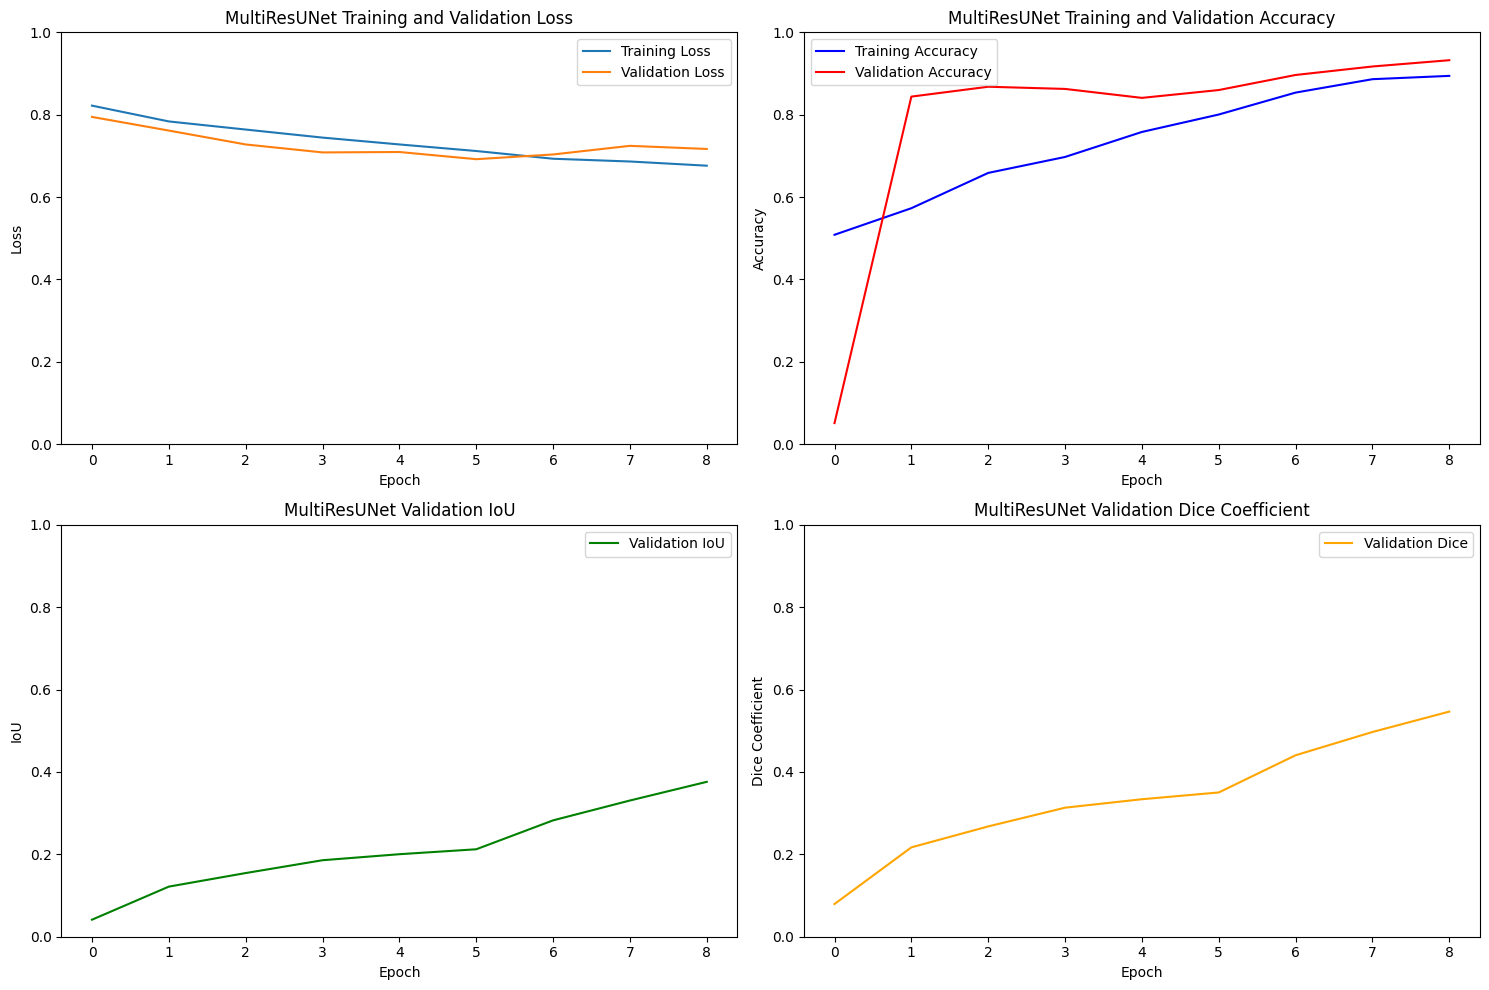

In [43]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

ax1.plot(train_losses, label='Training Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_ylim(0, 1)
ax1.legend()
ax1.set_title('MultiResUNet Training and Validation Loss')

ax2.plot(train_accs, label='Training Accuracy', color='blue')
ax2.plot(val_accs, label='Validation Accuracy', color='red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.set_title('MultiResUNet Training and Validation Accuracy')

ax3.plot(val_ious, label='Validation IoU', color='green')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('IoU')
ax3.set_ylim(0, 1)
ax3.legend()
ax3.set_title('MultiResUNet Validation IoU')

ax4.plot(val_dices, label='Validation Dice', color='orange')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Dice Coefficient')
ax4.set_ylim(0, 1)
ax4.legend()
ax4.set_title('MultiResUNet Validation Dice Coefficient')

plt.tight_layout()
plt.savefig('BSP_MultiResUNet_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## Test Evaluation

Loading best MultiResUNet model for test evaluation...

Evaluating MultiResUNet on test set...


Val batch: 100%|██████████| 13/13 [00:00<00:00, 28.60it/s]



TEST EVALUATION METRICS
Configuration: MultiResUNet | dropout as U-Net: encoder block 4 = 0.15, bottleneck = 0.2, decoder = 0.15
Test set processed with batch_size=1
Loss:            0.680687
IoU:             0.2473
mIoU:            0.5578
Dice Coefficient: 0.3965
Accuracy:        0.8739
Precision:       0.2508
Recall:          0.9455
F1-Score:        0.3965
Confusion matrix (pixel-level):
[[709229 105411]
 [  2034  35294]]


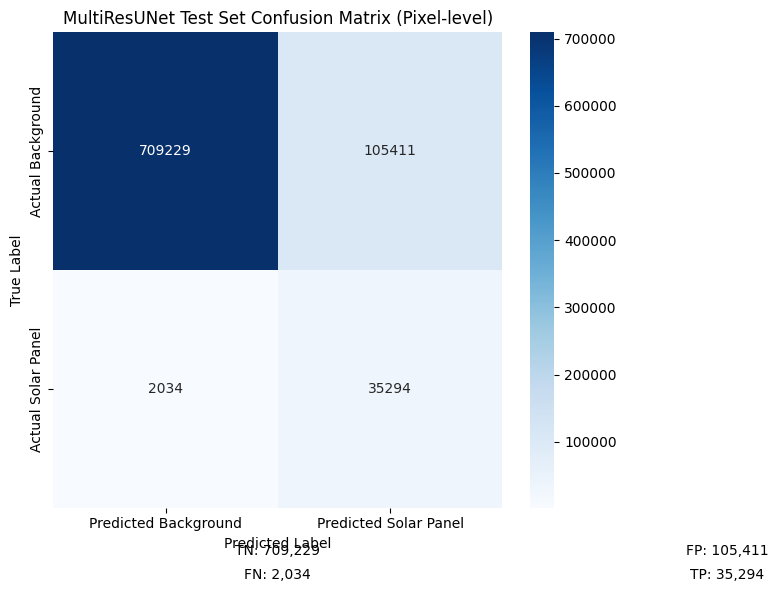

MultiResUNet training and evaluation completed!


In [44]:
print("Loading best MultiResUNet model for test evaluation...")
model.load_state_dict(torch.load('BSP_MultiResUNet.pth', map_location=device))
model.to(device)

print("\nEvaluating MultiResUNet on test set...")
test_metrics = validate(model, test_loader)

print("\n" + "="*50)
print("TEST EVALUATION METRICS")
print("Configuration: MultiResUNet | dropout as U-Net: encoder block 4 = 0.15, bottleneck = 0.2, decoder = 0.15")
print("="*50)
print(f"Test set processed with batch_size=1")
print(f"Loss:            {test_metrics['loss']:.6f}")
print(f"IoU:             {test_metrics['iou']:.4f}")
print(f"mIoU:            {test_metrics['miou']:.4f}")
print(f"Dice Coefficient: {test_metrics['dice']:.4f}")
print(f"Accuracy:        {test_metrics['acc']:.4f}")
print(f"Precision:       {test_metrics['precision']:.4f}")
print(f"Recall:          {test_metrics['recall']:.4f}")
print(f"F1-Score:        {test_metrics['f1']:.4f}")
print("Confusion matrix (pixel-level):")
print(test_metrics["confusion"])
print("="*50)

plt.figure(figsize=(8, 6))
cm = test_metrics["confusion"]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Background', 'Predicted Solar Panel'],
            yticklabels=['Actual Background', 'Actual Solar Panel'])
plt.title('MultiResUNet Test Set Confusion Matrix (Pixel-level)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.text(0.5, -0.1, f'TN: {cm[0,0]:,}', ha='center', transform=plt.gca().transAxes)
plt.text(1.5, -0.1, f'FP: {cm[0,1]:,}', ha='center', transform=plt.gca().transAxes)
plt.text(0.5, -0.15, f'FN: {cm[1,0]:,}', ha='center', transform=plt.gca().transAxes)
plt.text(1.5, -0.15, f'TP: {cm[1,1]:,}', ha='center', transform=plt.gca().transAxes)

plt.tight_layout()
plt.savefig('BSP_MultiResUNet_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("MultiResUNet training and evaluation completed!")


## Test the model on images

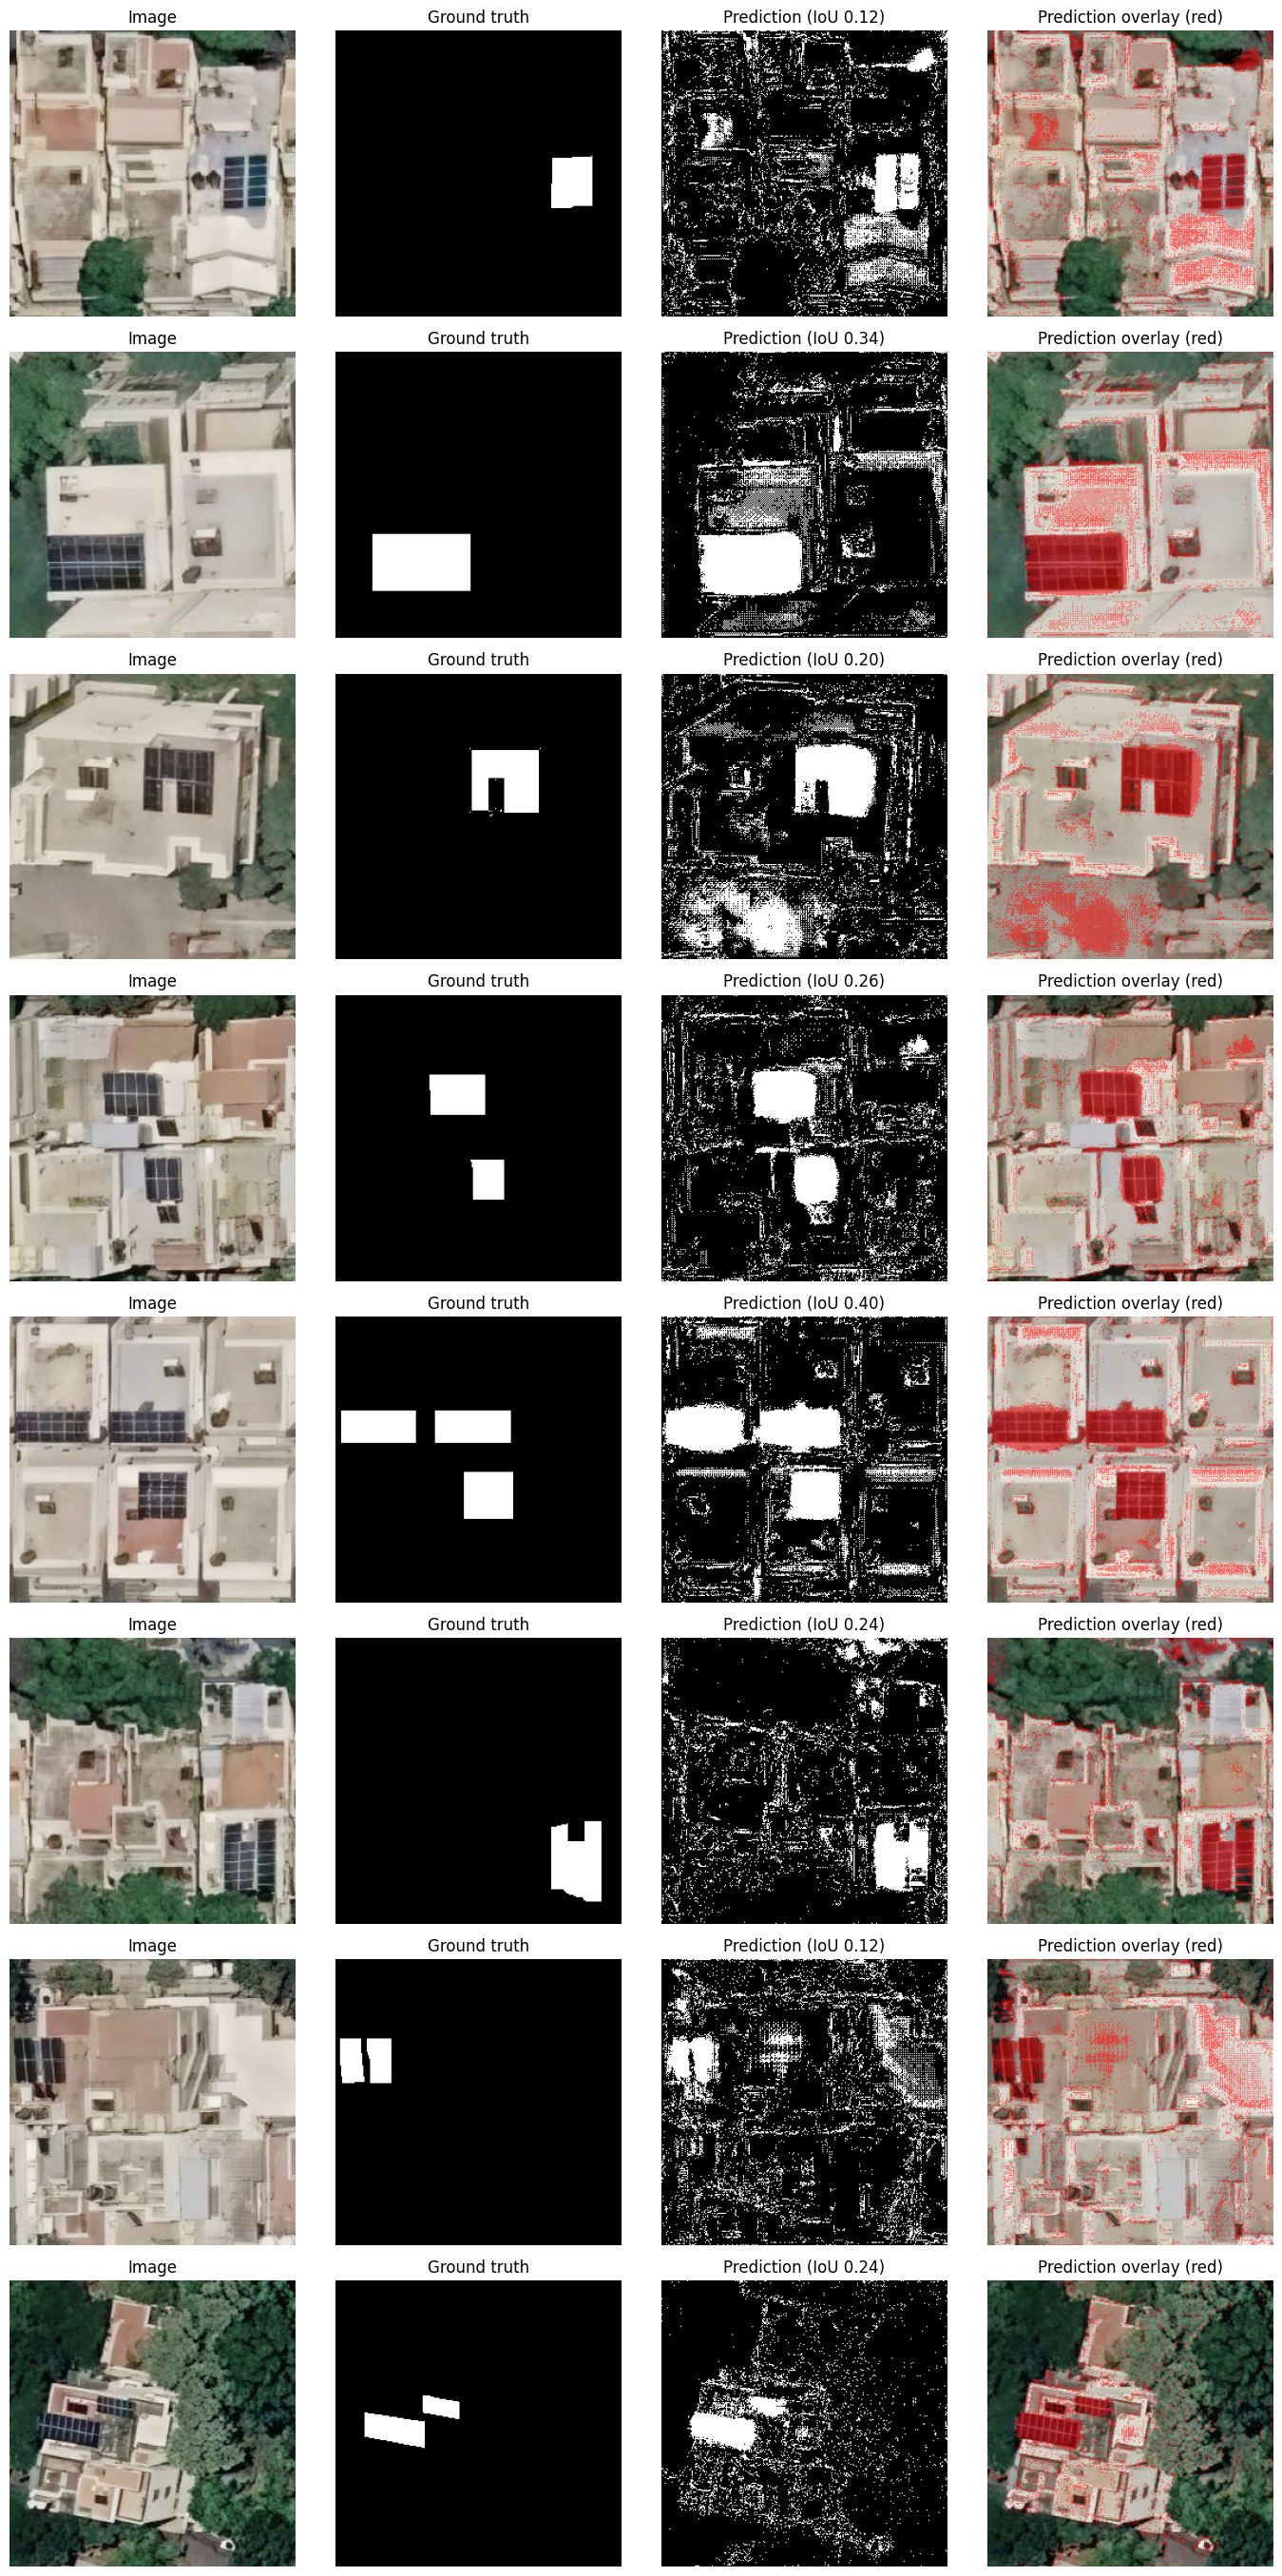

In [45]:
import random

root_dir = '/kaggle/input/datasets/icyyyyyy/bangaloresolarpanels/BangaloreSolarPanels'
IMG_SIZE = (256, 256)
FEATURES = [32, 64, 128, 256]
DROPOUT_RATE = 0.15
CKPT = 'BSP_MultiResUNet.pth'

# rebuild the test set and load the best checkpoint
tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
test_ds = SegDataset(root_dir, split='test', transform=tf, img_size=IMG_SIZE)

net = MultiResUNet(in_channels=3, out_channels=1, features=FEATURES, dropout_rate=DROPOUT_RATE).to(device)
net.load_state_dict(torch.load(CKPT, map_location=device))
net.eval()

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def show_predictions(n=8, seed=0, thresh=0.5):
    random.seed(seed)
    idxs = random.sample(range(len(test_ds)), n)
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.4 * n))
    for r, i in enumerate(idxs):
        img, gt = test_ds[i]
        with torch.no_grad():
            prob = torch.sigmoid(net(img.unsqueeze(0).to(device)))[0, 0].cpu()
        pred = (prob >= thresh).float()

        rgb = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        gt_np, pred_np = gt[0].numpy(), pred.numpy()

        inter = (gt_np * pred_np).sum()
        union = gt_np.sum() + pred_np.sum() - inter
        iou = inter / union if union > 0 else float('nan')

        overlay = rgb.copy()
        overlay[pred_np > 0] = 0.5 * overlay[pred_np > 0] + 0.5 * np.array([1, 0, 0])

        axes[r, 0].imshow(rgb);                  axes[r, 0].set_title("Image")
        axes[r, 1].imshow(gt_np, cmap='gray');   axes[r, 1].set_title("Ground truth")
        axes[r, 2].imshow(pred_np, cmap='gray'); axes[r, 2].set_title(f"Prediction (IoU {iou:.2f})")
        axes[r, 3].imshow(overlay);              axes[r, 3].set_title("Prediction overlay (red)")
        for a in axes[r]: a.axis('off')
    plt.tight_layout()
    plt.savefig('BSP_MultiResUNet_predictions.png', dpi=200, bbox_inches='tight')
    plt.show()

show_predictions(n=8, seed=0)
